# DE EIA - Projets applicatifs

2025-26 - Bordeaux INP - ENSEIRB-MATMECA

Michaël Clément

## Détection de la maladie d'Alzheimer à partir d'IRM du cerveau

Ce projet a pour objectif de développer un modèle de deep learning capable de classifier la maladie d'Alzheimer à partir d'IRM du cerveau.

Ce type d'outil peut notamment aider au diagnostic précoce de la maladie.

Le dataset que nous allons utiliser est tiré du projet Alzheimer's Disease Neuroimaging Initiative (ADNI). Il comprend plus de 700 IRM 3D d'environ 200x200x200 voxels, avec une résolution anatomique d'environ 1 mm par voxel.

Ces IRM sont réparties en plusieurs catégories cliniques :

- Cognitively Normal (CN) : sujets sains
- Alzheimer’s Disease (AD) : patients atteints de la maladie d'Alzheimer
- Mild Cognitive Impairment (MCI) : patients présentant des troubles cognitifs légers. Parmi les MCI, on distingue :
    - Stable MCI (sMCI) : troubles stables.
    - Progressive MCI (pMCI) : troubles évoluant vers l'AD.

D’un point de vue clinique, la distinction entre sMCI et pMCI est cruciale, car elle aide à identifier les patients à plus haut risque de progresser vers la maladie d’Alzheimer.

Cependant, les données sont souvent limitées pour ces catégories. En imagerie médicale, il est donc courant d'entraîner des modèles sur la classification CN/AD, puis de tester leur capacité à distinguer les cas sMCI/pMCI.

### Approches possibles

- Une approche simplifiée en utilisant une seule coupe d'IRM. Les images correspondant à la coupe axiale centrale de chaque volume vous sont fournies. L'objectif sera de mettre en place un système de classification CN/AD à partir de ces images 2D.
- Cette approche pourrait être étendue à du 2,5D, ou l'on va traiter un ensemble de coupes selon un ou plusieurs axes. Les coupes sont données comme des canaux supplémentaires et le réseau reste en 2D.
- Un modèle 3D peut être mis en place afin de prendre en compte tout le volume ou un sous-volume (par exemple la région de l'hippocampe). Attention, cette approche est très couteuse en mémoire et en temps de calcul, il sera nécessaire de diminuer fortement la taille des volumes et l'entraînement prendra plus de temps.

Le code de démarrage fourni vous permet de charger les données soit au format 2D (coupe axiale centrale), soit au format 3D (volumes complets), en spécifiant bien les chemins vers les répertoires des données 2D ou 3D que vous aurez téléchargé.
Les labels et les splits train/test sont spécifiés dans des fichiers `.txt` également fournis avec le sujet.

In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import numpy as np
import skimage
import nibabel
import matplotlib.pyplot as plt
import os


In [15]:
class AdniDataset(Dataset):
    def __init__(self, data_file_path, data_dir, mode='2d', transform=None):
        # Vérification du mode de chargement
        if mode not in ['2d', '3d']:
            raise ValueError("Le mode doit être '2d' ou '3d'.")
        # Initialisation des attributs du dataset
        self.mode = mode
        self.data_dir = data_dir
        self.transform = transform
        self.samples = []
        self.label_names = {0: 'CN', 1: 'AD', 2: 'sMCI', 3: 'pMCI'}
        # Lecture du fichier .txt d'entrée pour collecter les bases des noms de fichiers et leurs labels
        with open(data_file_path, 'r') as f:
            for line in f:
                line = line.strip()
                if not line: continue
                # Diviser la ligne en base du nom de fichier et label, puis convertir le label en entier
                filename_base_from_txt, label_str = line.split(',')
                label = int(label_str)
                self.samples.append((filename_base_from_txt, label)) # Ajouter l'échantillon à la liste
        
    def __len__(self):
        # Retourne le nombre total d'échantillons dans le dataset
        return len(self.samples)

    def __getitem__(self, idx):
        # Convertir idx en int si nécessaire (DataLoader peut passer d'autres types numériques)
        idx = int(idx)

        # Récupère la base du nom de fichier et le label pour l'échantillon donné
        filename_base, label = self.samples[idx]

        # Chargement des données en mode 2D (coupe axiale PNG)
        if self.mode == '2d':
            slice_filename_png = f"{filename_base}.png"
            slice_path = os.path.join(self.data_dir, slice_filename_png)
            
            # Charge l'image PNG avec skimage en niveaux de gris
            img_np = skimage.io.imread(slice_path, as_gray=True)
            tensor = torch.tensor(img_np, dtype=torch.float32).unsqueeze(0) 
        
        # Chargement des données en mode 3D (volume IRM complet)
        elif self.mode == '3d':
            filename_full = f"{filename_base}.nii.gz"
            img_path = os.path.join(self.data_dir, filename_full)
            
            # Charge le volume IRM 3D avec nibabel
            img = nibabel.load(img_path)
            data = np.array(img.get_data())
            tensor = torch.tensor(data, dtype=torch.float32).unsqueeze(0) 

        if self.transform:
            tensor = self.transform(tensor)
            
        return tensor, torch.tensor(label, dtype=torch.long)

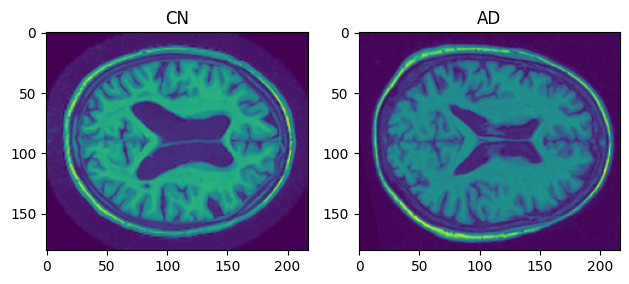

In [16]:
adni = AdniDataset('dataset/train_adcn.txt', 'dataset/2D_slices/', mode='2d')

plt.subplot(121)
im, y = adni[0]
plt.imshow(im[0])
plt.title(f'{adni.label_names[y.item()]}')

plt.subplot(122)
im, y = adni[2]
plt.imshow(im[0])
plt.title(f'{adni.label_names[y.item()]}')
plt.tight_layout()

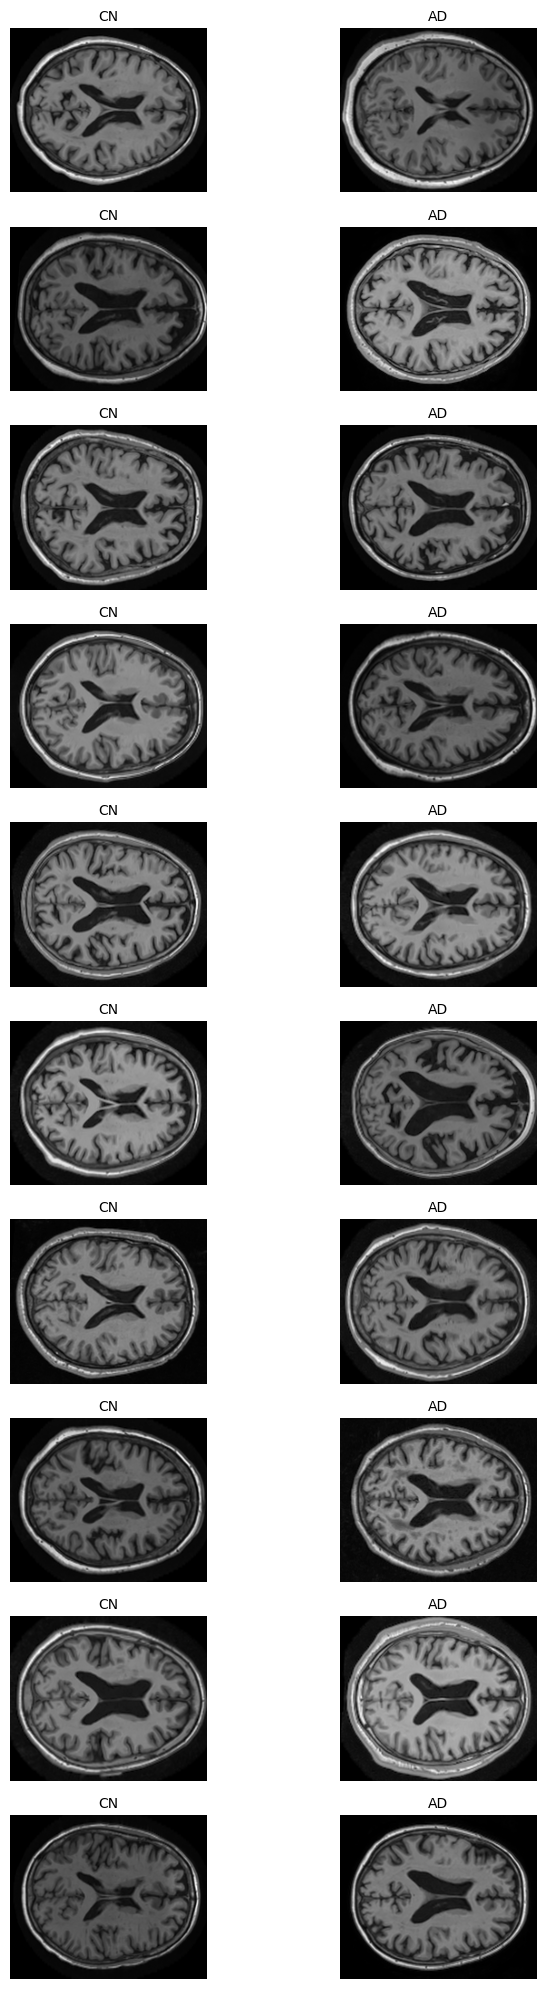

In [ ]:
# Afficher 10x2 images aléatoires : CN (gauche) et AD (droite)
fig, axes = plt.subplots(10, 2, figsize=(4, 20))

# Obtenir les indices des images CN (label 0) et AD (label 1)
cn_indices = [i for i in range(len(adni)) if adni.samples[i][1] == 0]
ad_indices = [i for i in range(len(adni)) if adni.samples[i][1] == 1]

# Mélanger et sélectionner 10 images aléatoires pour chaque label
import random
random.seed(42)
random_cn_indices = random.sample(cn_indices, min(10, len(cn_indices)))
random_ad_indices = random.sample(ad_indices, min(10, len(ad_indices)))

# Afficher les images
for row in range(10):
    # Colonne gauche : CN
    im_cn, y_cn = adni[random_cn_indices[row]]
    axes[row, 0].imshow(im_cn[0], cmap='gray')
    axes[row, 0].set_title(adni.label_names[y_cn.item()], fontsize=10)
    axes[row, 0].axis('off')
    
    # Colonne droite : AD
    im_ad, y_ad = adni[random_ad_indices[row]]
    axes[row, 1].imshow(im_ad[0], cmap='gray')
    axes[row, 1].set_title(adni.label_names[y_ad.item()], fontsize=10)
    axes[row, 1].axis('off')

plt.tight_layout()

In [25]:
# Afficher les statistiques du train set 2D
print("=" * 60)
print("STATISTIQUES DU TRAIN SET 2D (ADNI Dataset)")
print("=" * 60)

# Nombre total d'images
total_samples = len(adni)
print(f"\nNombre total d'images : {total_samples}")

# Compter par label
label_counts = {}
for i in range(len(adni)):
    label = adni.samples[i][1]
    label_counts[label] = label_counts.get(label, 0) + 1

print(f"\nRépartition par classe :")
for label_id, count in sorted(label_counts.items()):
    label_name = adni.label_names[label_id]
    percentage = (count / total_samples) * 100
    print(f"  {label_name} (label {label_id}): {count:4d} images ({percentage:6.2f}%)")

# Obtenir les dimensions des images
im, y = adni[0]
print(f"\nDimensions des images : {im.shape}")
print(f"  - Canaux : {im.shape[0]}")
print(f"  - Hauteur : {im.shape[1]}")
print(f"  - Largeur : {im.shape[2]}")

# Statistiques sur l'intensité
print(f"\nIntensité des pixels (premier échantillon) :")
print(f"  - Min : {im.min().item():.4f}")
print(f"  - Max : {im.max().item():.4f}")
print(f"  - Moyenne : {im.mean().item():.4f}")
print(f"  - Écart-type : {im.std().item():.4f}")

print("\n" + "=" * 60)

STATISTIQUES DU TRAIN SET 2D (ADNI Dataset)

Nombre total d'images : 314

Répartition par classe :
  CN (label 0):  171 images ( 54.46%)
  AD (label 1):  143 images ( 45.54%)

Dimensions des images : torch.Size([1, 181, 217])
  - Canaux : 1
  - Hauteur : 181
  - Largeur : 217

Intensité des pixels (premier échantillon) :
  - Min : 0.0000
  - Max : 255.0000
  - Moyenne : 68.2732
  - Écart-type : 59.1096

